In [1]:
import pandas as pd
print(pd.__version__)

3.0.6


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("D:/Energy-Analysis/data/household_power_consumption.txt",sep=";",na_values=["?"],low_memory=False)
df.head

<bound method NDFrame.head of                Date      Time  Global_active_power  Global_reactive_power  \
0        16/12/2006  17:24:00                4.216                  0.418   
1        16/12/2006  17:25:00                5.360                  0.436   
2        16/12/2006  17:26:00                5.374                  0.498   
3        16/12/2006  17:27:00                5.388                  0.502   
4        16/12/2006  17:28:00                3.666                  0.528   
...             ...       ...                  ...                    ...   
2075254  26/11/2010  20:58:00                0.946                  0.000   
2075255  26/11/2010  20:59:00                0.944                  0.000   
2075256  26/11/2010  21:00:00                0.938                  0.000   
2075257  26/11/2010  21:01:00                0.934                  0.000   
2075258  26/11/2010  21:02:00                0.932                  0.000   

         Voltage  Global_intensity  Sub_meter

In [4]:
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%Y %H:%M:%S")
df = df.drop(columns=["Date", "Time"])
df = df.set_index("datetime").sort_index()
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
print(df.shape)
print(df.index.min(), df.index.max())
print(df.isna().sum())

(2075259, 7)
2006-12-16 17:24:00 2010-11-26 21:02:00
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [6]:
missing_before = df["Global_active_power"].isna().mean() * 100
df = df.interpolate(method="time", limit=60)
missing_after = df["Global_active_power"].isna().mean() * 100
print(f"Missing: {missing_before:.2f}% -> {missing_after:.2f}%")

Missing: 1.25% -> 1.21%


In [7]:
hourly = df["Global_active_power"].resample("h").mean().dropna()
hourly.name = "kwh"
hourly.head()

datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Name: kwh, dtype: float64

In [8]:
daily = df["Global_active_power"].resample("D").mean() * 24
monthly = daily.resample("MS").mean()
monthly.head()

datetime
2006-12-01    46.890243
2007-01-01    37.106073
2007-02-01    33.629064
2007-03-01    31.646624
2007-04-01    21.101564
Freq: MS, Name: Global_active_power, dtype: float64

In [9]:
h = hourly.to_frame()
h["hour"] = h.index.hour
h["weekday"] = h.index.dayofweek      # 0 = Monday, 6 = Sunday
h["month"] = h.index.month
h["is_weekend"] = h["weekday"] >= 5
h.head()

,kwh,hour,weekday,month,is_weekend
datetime,,,,,
2006-12-16 17:00:00,4.222889,17,5,12,True
2006-12-16 18:00:00,3.632200,18,5,12,True
2006-12-16 19:00:00,3.400233,19,5,12,True
2006-12-16 20:00:00,3.268567,20,5,12,True
2006-12-16 21:00:00,3.056467,21,5,12,True


In [10]:
by_hour = h.groupby("hour")["kwh"].mean()
by_weekday = h.groupby("weekday")["kwh"].mean()
by_month = h.groupby("month")["kwh"].mean()
weekend_vs_weekday = h.groupby("is_weekend")["kwh"].mean()

print(by_hour.round(2))
print(weekend_vs_weekday.round(2))

hour
0     0.66
1     0.54
2     0.48
3     0.44
4     0.44
5     0.45
6     0.79
7     1.50
8     1.46
9     1.33
10    1.26
11    1.25
12    1.21
13    1.14
14    1.08
15    0.99
16    0.95
17    1.06
18    1.33
19    1.73
20    1.90
21    1.88
22    1.41
23    0.90
Name: kwh, dtype: float64
is_weekend
False    1.04
True     1.23
Name: kwh, dtype: float64


In [11]:
peak = h["hour"].between(18, 22)          # 6 PM to 10:59 PM
peak_share = h.loc[peak, "kwh"].sum() / h["kwh"].sum() * 100
print(f"Peak window (6-11 PM) carries {peak_share:.1f}% of total energy")
print("Top 3 hours:", by_hour.nlargest(3).index.tolist())
print("Lowest 3 hours:", by_hour.nsmallest(3).index.tolist())

Peak window (6-11 PM) carries 31.5% of total energy
Top 3 hours: [20, 21, 19]
Lowest 3 hours: [4, 3, 5]


In [12]:
sub = df[["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]].sum() / 1000   # Wh to kWh
total_kwh = df["Global_active_power"].sum() / 60
sub_share = sub / total_kwh * 100
print(sub_share.round(1))
print(f"Not covered by sub-meters: {100 - sub_share.sum():.1f}%")

Sub_metering_1     6.2
Sub_metering_2     7.1
Sub_metering_3    35.5
dtype: float64
Not covered by sub-meters: 51.2%


In [13]:
print(weekend_vs_weekday.round(2))
print("Highest month:", by_month.idxmax(), round(by_month.max(), 2))
print("Lowest month:", by_month.idxmin(), round(by_month.min(), 2))

is_weekend
False    1.04
True     1.23
Name: kwh, dtype: float64
Highest month: 12 1.49
Lowest month: 8 0.57


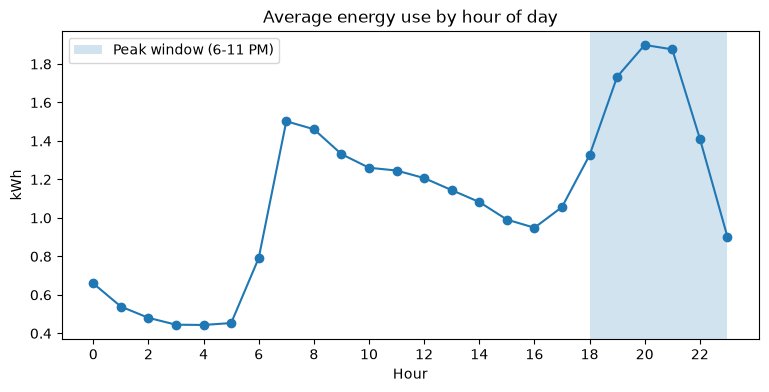

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(by_hour.index, by_hour.values, marker="o")
ax.axvspan(18, 22.99, alpha=0.2, label="Peak window (6-11 PM)")
ax.set_title("Average energy use by hour of day")
ax.set_xlabel("Hour")
ax.set_ylabel("kWh")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.savefig("images/by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

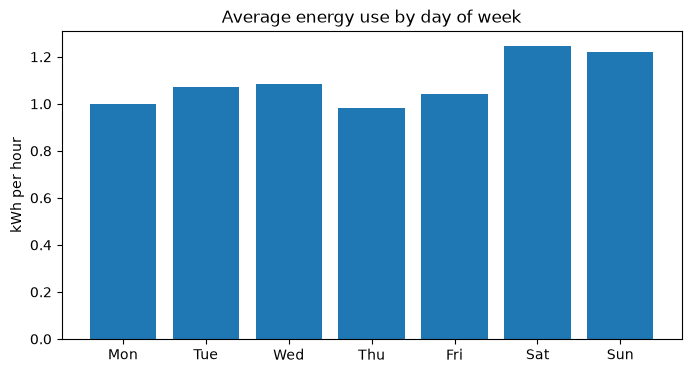

In [15]:
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(days, by_weekday.values)
ax.set_title("Average energy use by day of week")
ax.set_ylabel("kWh per hour")
plt.savefig("images/by_weekday.png", dpi=150, bbox_inches="tight")
plt.show()

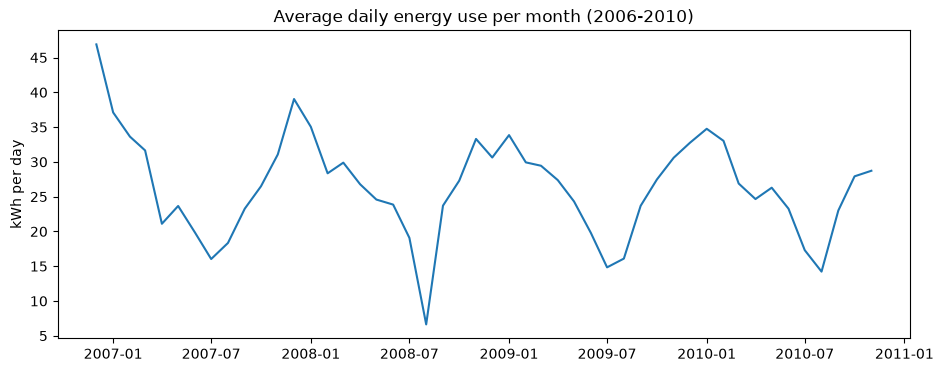

In [16]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly.index, monthly.values)
ax.set_title("Average daily energy use per month (2006-2010)")
ax.set_ylabel("kWh per day")
plt.savefig("images/monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()

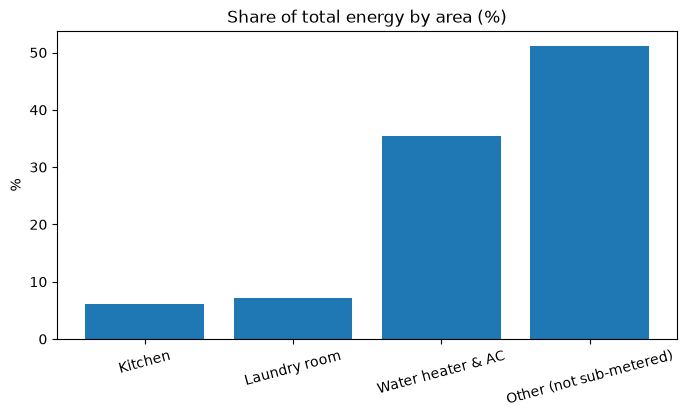

In [17]:
shares = sub_share.copy()
shares.index = ["Kitchen", "Laundry room", "Water heater & AC"]
shares["Other (not sub-metered)"] = 100 - shares.sum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(shares.index, shares.values)
ax.set_title("Share of total energy by area (%)")
ax.set_ylabel("%")
plt.xticks(rotation=15)
plt.savefig("images/energy_share.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
win = 24 * 7                                  # 7 days of hourly data
base = hourly.shift(1)                        # exclude the current hour from its own baseline
roll_mean = base.rolling(win, min_periods=100).mean()
roll_std = base.rolling(win, min_periods=100).std()
z = (hourly - roll_mean) / roll_std
z.describe()

count    34076.000000
mean         0.007118
std          1.078052
min         -2.076517
25%         -0.814745
50%         -0.281691
75%          0.591623
max         50.898652
Name: kwh, dtype: float64

In [19]:
anom = hourly[z.abs() > 3]
spikes = hourly[z > 3]
drops = hourly[z < -3]

print(f"Anomalies: {len(anom)} of {len(hourly)} hours ({len(anom)/len(hourly)*100:.2f}%)")
print(f"Spikes: {len(spikes)} | Drops: {len(drops)}")

Anomalies: 470 of 34176 hours (1.38%)
Spikes: 470 | Drops: 0


In [20]:
print(z.abs().nlargest(10).round(1))

datetime
2008-08-31 14:00:00    50.9
2008-08-31 15:00:00    19.4
2008-08-31 17:00:00    10.5
2007-03-04 17:00:00     9.5
2007-03-04 16:00:00     9.5
2008-08-31 16:00:00     9.5
2009-08-09 18:00:00     9.4
2009-08-09 17:00:00     9.0
2007-03-04 19:00:00     9.0
2007-03-04 18:00:00     7.7
Name: kwh, dtype: float64


In [21]:
print(anom.groupby(anom.index.hour).size())

datetime
0     11
1      5
2      2
3      2
4      1
7      7
8      8
9      5
10    11
11    16
12    21
13    17
14    11
15    19
16    19
17    26
18    41
19    64
20    66
21    79
22    25
23    14
Name: kwh, dtype: int64


Busiest month: 2010-08 28 anomalies


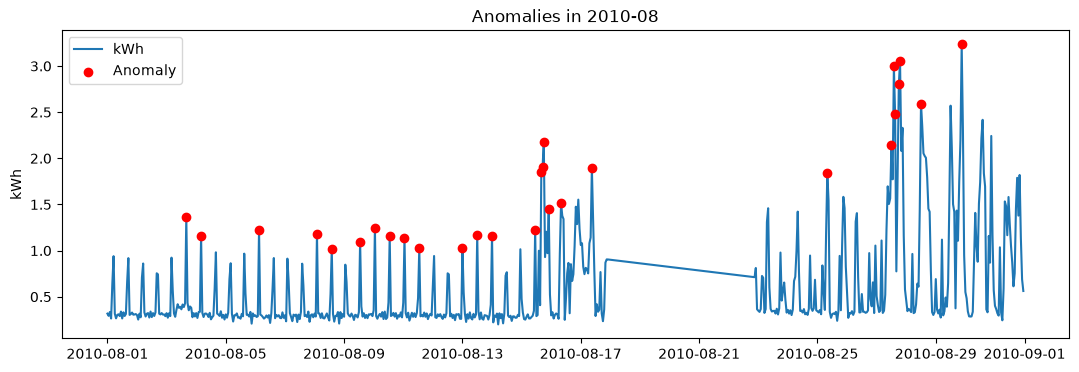

In [22]:
month_counts = anom.groupby(anom.index.to_period("M")).size()
busiest = month_counts.idxmax()
print("Busiest month:", busiest, month_counts.max(), "anomalies")

start, end = busiest.start_time, busiest.end_time
sample = hourly[start:end]
a = anom[start:end]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(sample.index, sample.values, label="kWh")
ax.scatter(a.index, a.values, color="red", zorder=3, label="Anomaly")
ax.set_title(f"Anomalies in {busiest}")
ax.set_ylabel("kWh")
ax.legend()
plt.savefig("images/anomalies.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
print("Spike examples:")
print(spikes.nlargest(3))
print("Drop examples (lowest usage):")
print(drops.nsmallest(3))

Spike examples:
datetime
2008-11-23 18:00:00    6.560533
2009-01-16 20:00:00    6.519633
2008-02-02 19:00:00    6.496033
Name: kwh, dtype: float64
Drop examples (lowest usage):
Series([], Name: kwh, dtype: float64)


In [24]:
daily_base = daily.shift(1).rolling(30, min_periods=15).median()
low_days = daily[daily < 0.4 * daily_base]
print(f"Low-usage days: {len(low_days)} of {len(daily)}")
print(low_days.groupby(low_days.index.to_period("M")).size().nlargest(5))

Low-usage days: 43 of 1442
datetime
2008-08    13
2007-02     5
2008-02     4
2007-04     3
2007-03     2
Freq: M, Name: Global_active_power, dtype: int64


In [25]:
gaps = hourly.index.to_series().diff()
big = gaps[gaps > pd.Timedelta("2h")]
print(f"Gaps longer than 2 hours: {len(big)}")
print(big.nlargest(5))

Gaps longer than 2 hours: 7
datetime
2010-08-22 21:00:00   4 days 23:00:00
2010-09-28 19:00:00   3 days 15:00:00
2007-04-30 14:00:00   2 days 13:00:00
2009-06-15 07:00:00   2 days 06:00:00
2010-01-14 19:00:00   2 days 04:00:00
Name: datetime, dtype: timedelta64[us]
